# 02. Gender equity mismatch and fertility across the OECD

Part two of the Korea project. The first notebook showed that one country's time
series cannot really test the mismatch hypothesis, since every equity variable
trended along with fertility, and a standardized mismatch measures pace along a
trajectory rather than the absolute gap the theory is about. This notebook runs the
test the theory actually calls for, which is a comparison across countries.

We limit the comparison to the 38 OECD members so that the level of development,
health systems and access to contraception are roughly held constant. Comparing Korea
with a poor country at high fertility would mix up gender equity with poverty.

Every measure is in absolute terms, as a percentage of gender parity, so the mismatch
is the real distance between the spheres rather than a position relative to a
country's own history.

**Inputs** (from `00_pull_data.ipynb`, in `data/raw/`): `oecd_worldbank_annual.csv`,
`oecd_time_use.csv`.

**Outputs**: `data/processed/oecd_mismatch.csv` (one row per country, 30 rows, every
variable used here plus the mismatch), figures `output/fig02_*.png`, and
`output/table_oecd_sample.csv` (Table 2 in the paper).

| Sphere | Measure | Parity of 100 means | Source |
|---|---|---|---|
| Outcome | Total fertility rate, latest | | World Bank |
| Public | Ratio of female to male labour force participation | women take part as much as men | World Bank / ILO |
| Public | Tertiary enrolment gender parity index | women enrol as much as men | World Bank / UNESCO |
| Private | Men's share of unpaid work divided by 50 | men do half the unpaid work | OECD Time Use Database |
| Control | GDP per capita at PPP | | World Bank |

## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utils import (
    DATA_RAW, DATA_PROCESSED, OECD_MEMBERS, KOREA_CODE,
    latest_per_country, share_pct, build_public_private_parity,
    report_merge, save_figure, save_table, bar_chart, scatter_with_labels, spaghetti,
)

pd.set_option("display.width", 130)

# The cross-section uses each country's latest value at or before this year. The
# World Bank keeps adding years, so freezing the snapshot keeps the results
# reproducible. 2024 is the latest year with fertility data for every member.
SNAPSHOT_YEAR = 2024

## 1. World Bank cross-section

We collapse the long annual panel to one row per country by taking the latest value
that is not missing for each indicator at or before the snapshot year. The `_year`
columns record which year each value comes from. Most are 2023 or 2024, with tertiary
parity going back to 2019 for a few countries.

In [2]:
panel = pd.read_csv(DATA_RAW / "oecd_worldbank_annual.csv")
print("Panel rows:", len(panel), "| countries:", panel["code"].nunique())

wb = latest_per_country(panel, max_year=SNAPSHOT_YEAR)
wb.insert(1, "country", wb["code"].map(OECD_MEMBERS))
print("Countries in cross-section:", len(wb))
print("Year of value used, by indicator:")
print(wb[[c for c in wb.columns if c.endswith("_year")]].describe().loc[["min", "max"]].astype(int))
wb[["country", "tfr", "tfr_year", "lfp_ratio", "tertiary_gpi", "tertiary_gpi_year", "gdp_pc"]].head(8)

Panel rows: 6061 | countries: 38
Countries in cross-section: 38
Year of value used, by indicator:
     gdp_pc_year  lfp_ratio_year  tertiary_gpi_year  tfr_year
min         2024            2024               2019      2024
max         2024            2024               2024      2024


,country,tfr,tfr_year,lfp_ratio,tertiary_gpi,tertiary_gpi_year,gdp_pc
0,Australia,1.481,2024,88.337235,1.31058,2024,60309.583177
1,Austria,1.310,2024,84.152972,1.23400,2024,63787.989175
2,Belgium,1.440,2024,84.269284,1.27316,2023,63311.276692
3,Canada,1.250,2024,87.344041,1.26879,2023,57534.091519
4,Switzerland,1.290,2024,87.102481,1.12194,2024,85448.058558
5,Chile,1.140,2024,73.291770,1.15266,2024,30267.644092
6,Colombia,1.634,2024,68.175107,1.15419,2022,18481.837493
7,Costa Rica,1.318,2024,65.823038,1.17723,2019,27325.047048


## 2. OECD time use

Minutes per day of unpaid work by sex, one survey per country, pulled and saved by
notebook 00. We convert men's share to a percentage of parity by dividing by 50.

In [3]:
timeuse = pd.read_csv(DATA_RAW / "oecd_time_use.csv")
timeuse["men_share_unpaid_pct"] = share_pct(timeuse["men_unpaid_min"], timeuse["women_unpaid_min"])
print("OECD members with time-use data:", len(timeuse))

OECD members with time-use data: 30


## 3. Combine and build the mismatch

An inner join on the ISO3 country code, which drops the eight members without a time
use survey (Chile, Colombia, Costa Rica, Czechia, Iceland, Israel, Slovakia,
Switzerland). Then:

- Public parity is the average of the labour force participation ratio and tertiary
  parity, where 100 is parity in both.
- Private parity is men's share of unpaid work as a percentage of parity.
- The mismatch is public parity minus private parity. A country where women work and
  study like men, but where men do a fifth of the housework, scores high.

In [4]:
data = wb.merge(timeuse, on="code", how="inner")
report_merge(wb, timeuse, data, "World Bank + time use (inner)", "code")
dropped = sorted(set(wb["code"]) - set(data["code"]))
print("Dropped for lack of time-use data:", ", ".join(OECD_MEMBERS[c] for c in dropped))

data = build_public_private_parity(data)
data["log_gdp"] = np.log(data["gdp_pc"])
data = data.sort_values("mismatch", ascending=False).reset_index(drop=True)

save_table(data, "oecd_mismatch", folder=DATA_PROCESSED)

sample_table = data[["country", "tfr", "public_parity", "men_share_unpaid_pct",
                     "private_parity", "mismatch"]].round(1)
save_table(sample_table, "table_oecd_sample")
sample_table

[World Bank + time use (inner)] left: 38 rows, right: 30 rows, merged on 'code': 30 rows
Dropped for lack of time-use data: Switzerland, Chile, Colombia, Costa Rica, Czechia, Iceland, Israel, Slovakia
Saved table: data/processed/oecd_mismatch.csv
Saved table: output/table_oecd_sample.csv


,country,tfr,public_parity,men_share_unpaid_pct,private_parity,mismatch
0,Portugal,1.4,102.8,22.7,45.4,57.5
1,Japan,1.2,87.6,18.4,36.9,50.7
2,Korea,0.7,83.9,18.6,37.1,46.8
3,New Zealand,1.6,113.3,34.8,69.6,43.7
4,Türkiye,1.5,79.3,18.1,36.3,43.0
5,Ireland,1.5,101.8,30.3,60.5,41.3
6,Latvia,1.2,107.5,33.9,67.7,39.8
7,Italy,1.2,99.5,29.9,59.8,39.7
8,Lithuania,1.1,107.5,34.2,68.4,39.1
9,Australia,1.5,109.7,35.6,71.1,38.6


## 4. Each factor across the OECD

One bar chart per variable, sorted, with Korea highlighted.

Korea sits at the fertility floor by a wide margin, at 0.75 against roughly 1.1 for
the next lowest country. On the public side it falls below most of its peers, in the
lower group on labour force parity and lowest of all on tertiary parity. The tertiary
figure is partly a ratio effect, since Korean women enrol at very high rates but
Korean men enrol at even higher ones. On the private side Korea sits at the bottom
along with Japan and Türkiye, with men doing about 18 percent of unpaid work against
43 to 44 percent in the Nordic countries. Tertiary parity is above 100 almost
everywhere, since women now enrol more than men across the OECD.

Saved figure: output/fig02_oecd_components_bars.png


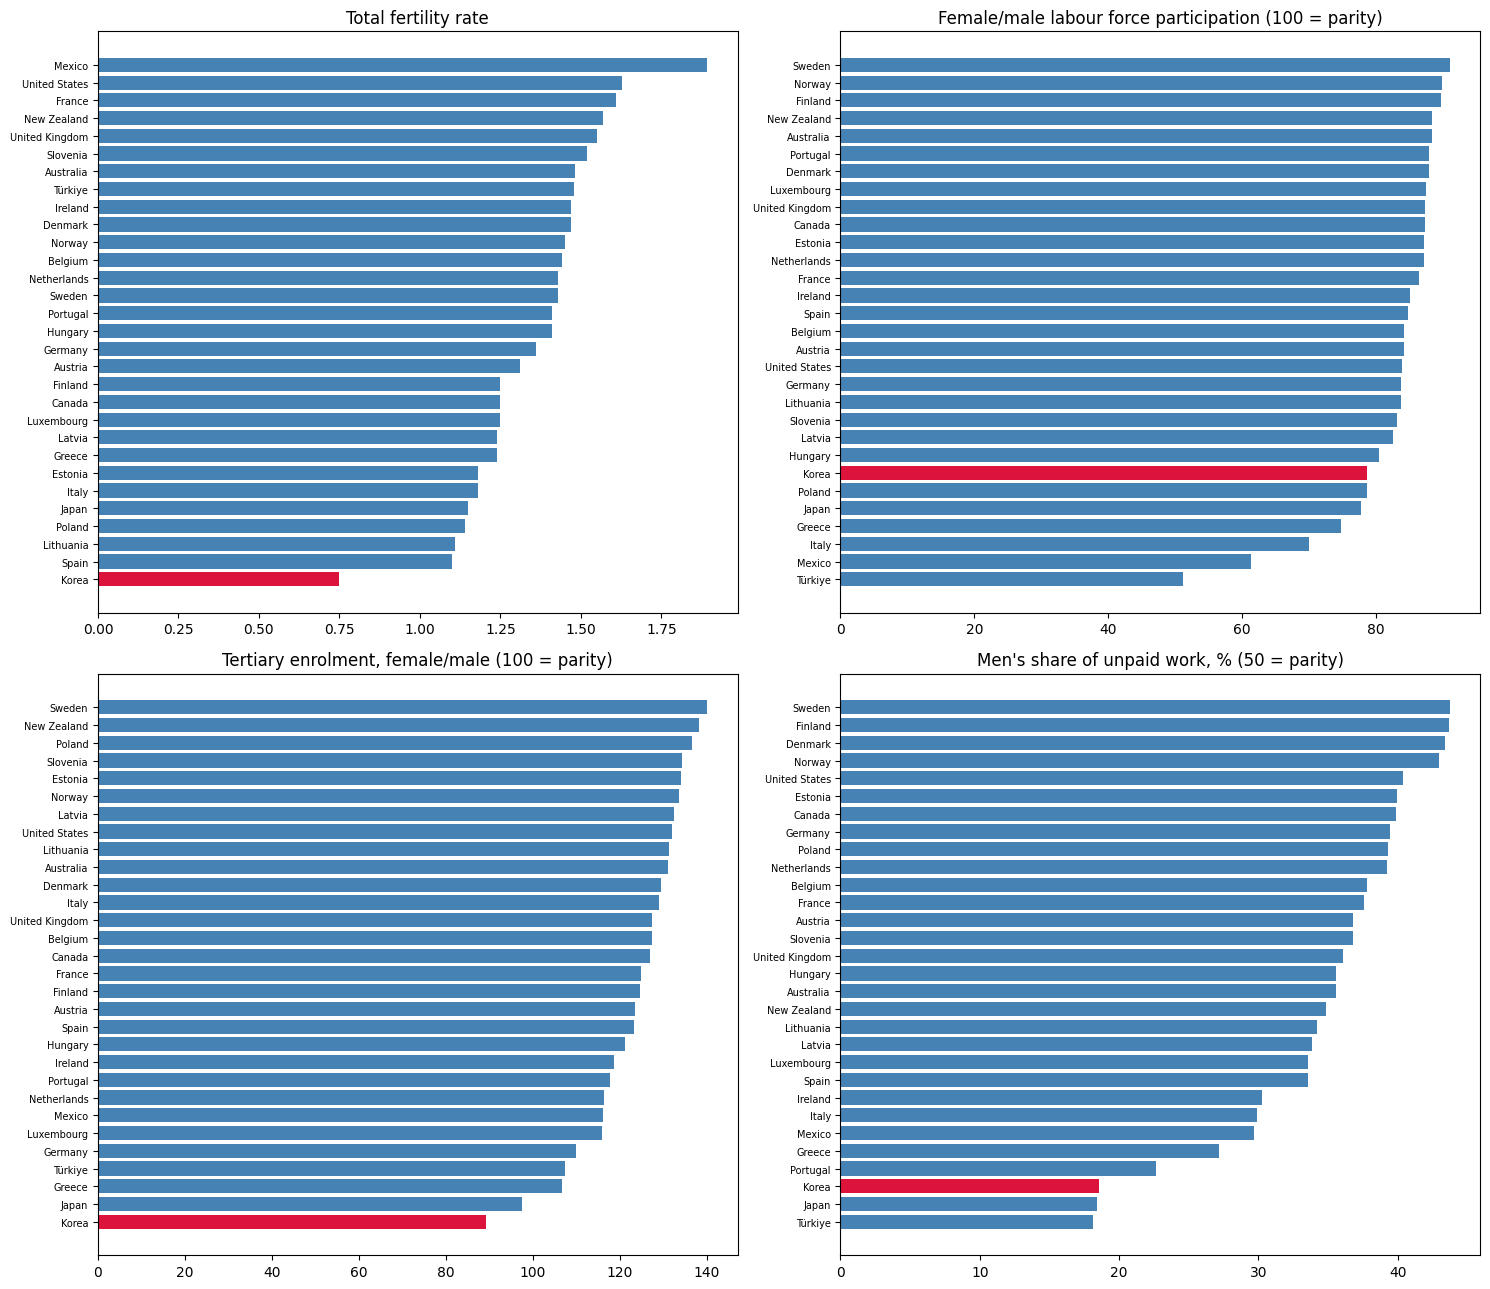

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(15, 13))
bar_chart(axes[0, 0], data, "tfr", "Total fertility rate")
bar_chart(axes[0, 1], data, "lfp_ratio", "Female/male labour force participation (100 = parity)")
bar_chart(axes[1, 0], data, "tertiary_parity", "Tertiary enrolment, female/male (100 = parity)")
bar_chart(axes[1, 1], data, "men_share_unpaid_pct", "Men's share of unpaid work, % (50 = parity)")
plt.tight_layout()
save_figure(fig, "fig02_oecd_components_bars")
plt.show()

## 5. The same variables over time

The time plots from the Korea notebook, repeated with one line per OECD country in
grey and Korea highlighted in red. We can only show this way the variables that exist
as annual series for every country, which leaves fertility, labour force parity and
tertiary parity. The private sphere measures cannot be shown, because the OECD time
use data is a single snapshot per country and fathers' leave by year is not available
across countries. So the private sphere appears only in the cross-sectional plots.

Saved figure: output/fig02_oecd_series_over_time.png


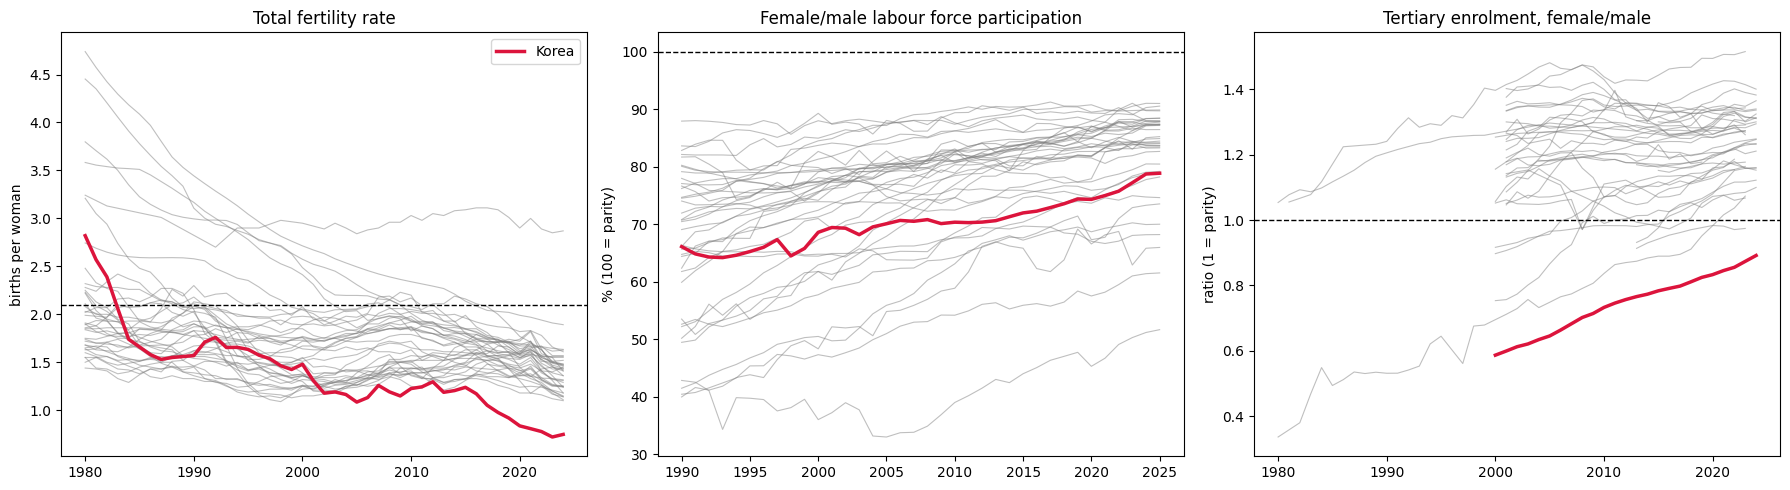

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

spaghetti(axes[0], panel, "tfr", "Total fertility rate", "births per woman")
axes[0].axhline(2.1, color="black", linestyle="--", linewidth=1)
axes[0].legend()

spaghetti(axes[1], panel, "lfp_ratio", "Female/male labour force participation", "% (100 = parity)", start_year=1990)
axes[1].axhline(100, color="black", linestyle="--", linewidth=1)

spaghetti(axes[2], panel, "tertiary_gpi", "Tertiary enrolment, female/male", "ratio (1 = parity)")
axes[2].axhline(1.0, color="black", linestyle="--", linewidth=1)

plt.tight_layout()
save_figure(fig, "fig02_oecd_series_over_time")
plt.show()

A cleaner way to compare fertility trajectories is to index every country to its own
value in 2000. That strips out the level and shows which countries fell fastest.

Saved figure: output/fig02_oecd_tfr_indexed_2000.png


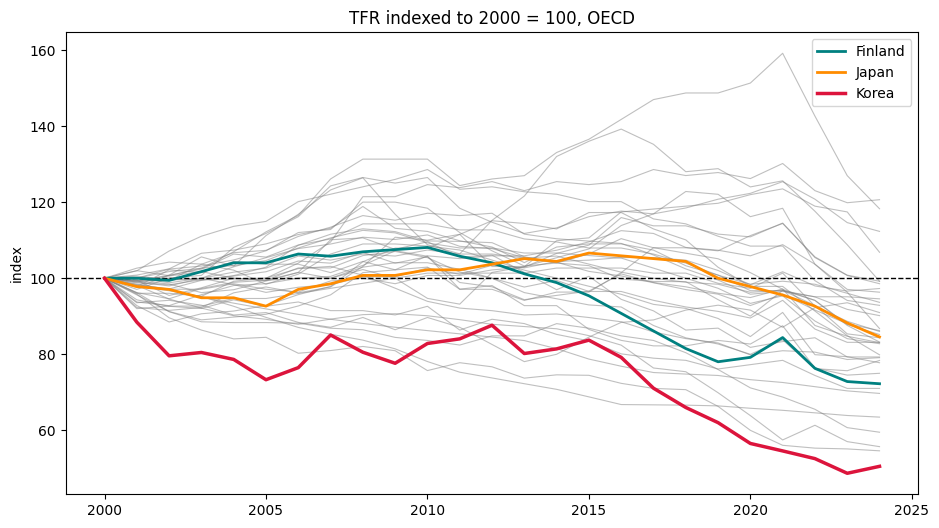

In [7]:
tfr_panel = panel[(panel["indicator"] == "tfr") & (panel["year"] >= 2000)].copy()
base = tfr_panel[tfr_panel["year"] == 2000].set_index("code")["value"]
tfr_panel["indexed"] = tfr_panel["value"] / tfr_panel["code"].map(base) * 100.0

highlight = {"KOR": ("crimson", 2.5), "JPN": ("darkorange", 2.0), "FIN": ("teal", 2.0)}

fig, ax = plt.subplots(figsize=(11, 6))
for code, series in tfr_panel.dropna(subset=["indexed"]).groupby("code"):
    if code in highlight:
        color, width = highlight[code]
        ax.plot(series["year"], series["indexed"], color=color, linewidth=width,
                label=OECD_MEMBERS[code], zorder=5)
    else:
        ax.plot(series["year"], series["indexed"], color="grey", linewidth=0.8, alpha=0.5)
ax.axhline(100, color="black", linestyle="--", linewidth=1)
ax.set_title("TFR indexed to 2000 = 100, OECD")
ax.set_ylabel("index")
ax.legend()
save_figure(fig, "fig02_oecd_tfr_indexed_2000")
plt.show()

Fertility fell across the whole OECD after about 2015. Most members were flat or
rising through the 2000s and then turned down together. Korea is not alone in
declining, only in how far it went: indexed to 2000 it lost about half its fertility,
while most members lost 10 to 25 percent. Finland, down about 28 percent, is the
steepest fall among the countries with equal households, and that is the awkward case
for the theory.

On the public side Korea sits below the OECD pack on both parity ratios rather than
inside it. Its ratio of female to male labour force participation is in the lower
group, though rising, and its tertiary ratio is the lowest in the OECD. The tertiary
figure is partly an artifact, since Korean women enrol at very high rates but Korean
men enrol at even higher ones, so a ratio understates where women actually stand.
Even so, on these measures Korea's public sphere is less equal than most of the OECD,
which works against the mismatch story, because the theory needs a public sphere that
is close to equal. This suggests that in Korea's case the sharpest contrast with its
peers is in the private sphere and in the level of fertility rather than in the
public sphere.

## 6. Each factor against fertility

Three scatter plots, one per variable, with the correlation shown in the title.

Neither measure of the public sphere relates to fertility in any clear way. Men's
share of housework is positively related to fertility at about 0.27, so countries
where men do more at home tend to have somewhat higher fertility. That is the
direction McDonald predicts, although the relationship is loose. Finland, Germany and
Poland have fairly equal households and low fertility, while Ireland and New Zealand
have unequal households and relatively high fertility.

Saved figure: output/fig02_oecd_components_vs_tfr.png


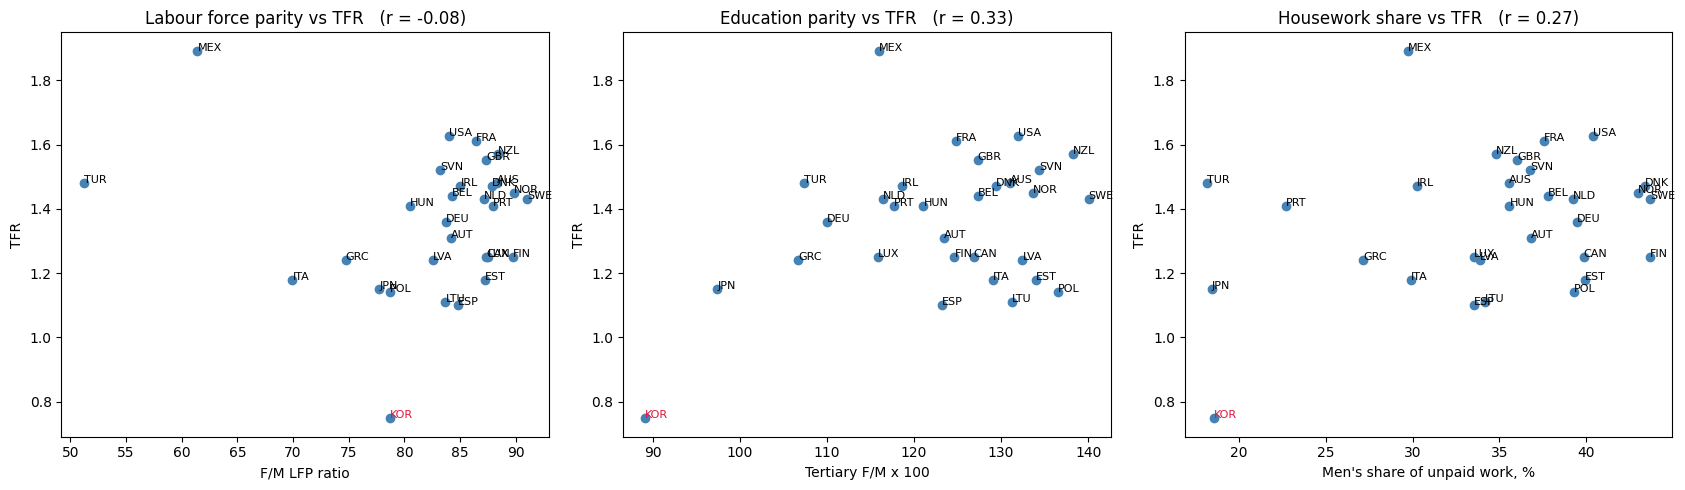

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
scatter_with_labels(axes[0], data, "lfp_ratio", "tfr", "F/M LFP ratio", "Labour force parity vs TFR")
scatter_with_labels(axes[1], data, "tertiary_parity", "tfr", "Tertiary F/M x 100", "Education parity vs TFR")
scatter_with_labels(axes[2], data, "men_share_unpaid_pct", "tfr", "Men's share of unpaid work, %", "Housework share vs TFR")
plt.tight_layout()
save_figure(fig, "fig02_oecd_components_vs_tfr")
plt.show()

## 7. Mismatch against fertility

This is the main test. The correlation is negative at about 0.25, so a higher
mismatch goes with lower fertility, which is the direction the theory predicts and
the opposite of what the standardized version within Korea produced. The cluster with
the lowest fertility, made up of Korea, Japan, Italy, Spain, Lithuania and Latvia,
sits on the high mismatch side. The relationship is weak, though, and that same side
also holds Portugal, New Zealand, Ireland and Türkiye at ordinary levels of
fertility. Two caveats about the data are worth noting. The time use surveys come
from different years, several of them 10 to 25 years old. And Korea is an extreme
outlier, sitting 0.4 births below the next country even among the countries with a
high mismatch, so something beyond the mismatch is going on there.

Saved figure: output/fig02_oecd_mismatch_vs_tfr.png


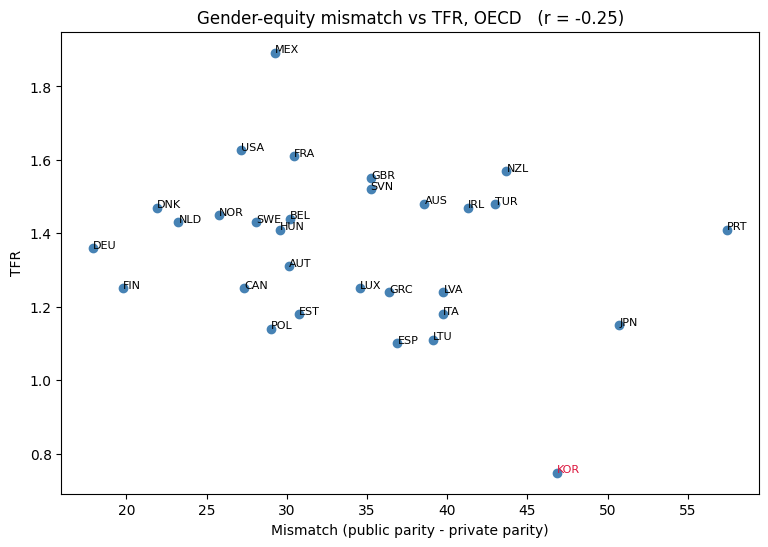

Correlation, mismatch vs TFR: -0.252 across 30 countries


In [9]:
fig, ax = plt.subplots(figsize=(9, 6))
scatter_with_labels(ax, data, "mismatch", "tfr", "Mismatch (public parity - private parity)",
                    "Gender-equity mismatch vs TFR, OECD")
save_figure(fig, "fig02_oecd_mismatch_vs_tfr")
plt.show()

r_mismatch = data["tfr"].corr(data["mismatch"])
print("Correlation, mismatch vs TFR:", round(r_mismatch, 3), "across", len(data), "countries")

## 8. High, middle and low mismatch groups

We split countries into three equal groups by mismatch and compare their average
fertility.

The gradient runs in the predicted direction, with the high mismatch countries
averaging 1.28, the middle group 1.36 and the low group 1.43, but the spread is only
0.15 births across the whole range. The theory seems to explain part of the ranking
rather than the level, since even the low mismatch group is far below replacement.
That fits the point from the literature review that gender equity explains why some
rich countries are lowest rather than why all of them are low.

In [10]:
group_order = ["High mismatch", "Mid mismatch", "Low mismatch"]
data["mismatch_group"] = pd.qcut(data["mismatch"], 3, labels=group_order[::-1])   # qcut labels low -> high

summary = (data.groupby("mismatch_group", observed=True)[["tfr", "mismatch", "public_parity", "private_parity"]]
           .mean().round(2).loc[group_order])
display(summary)
for label, members in data.groupby("mismatch_group", observed=True)["country"]:
    print(f"{label}: {', '.join(members)}")

,tfr,mismatch,public_parity,private_parity
mismatch_group,,,,
High mismatch,1.28,44.01,99.29,55.28
Mid mismatch,1.36,32.95,103.92,70.96
Low mismatch,1.43,24.95,105.32,80.36


Low mismatch: Mexico, Poland, Sweden, Canada, United States, Norway, Netherlands, Denmark, Finland, Germany
Mid mismatch: Spain, Greece, United Kingdom, Slovenia, Luxembourg, Estonia, France, Belgium, Austria, Hungary
High mismatch: Portugal, Japan, Korea, New Zealand, Türkiye, Ireland, Latvia, Italy, Lithuania, Australia


## 9. Does income explain it instead?

Richer countries could have both more equal households and different fertility for
reasons that have nothing to do with gender. A simple check is to remove the part of
each variable that GDP per capita explains, using a straight line fit on log GDP and
keeping the residuals, and then to correlate those residuals.

Within the OECD, income is unrelated to fertility at about 0.07, and removing it
leaves the mismatch and housework correlations essentially unchanged, at 0.27 in the
negative direction and 0.31 in the positive one. This suggests the relationship, such
as it is, is not an income effect in disguise.

In [11]:
def residual_after(frame, y_column, x_column):
    """Residuals of y after a straight-line fit on x."""
    slope, intercept = np.polyfit(frame[x_column], frame[y_column], 1)
    return frame[y_column] - (slope * frame[x_column] + intercept)


for column in ["tfr", "mismatch", "private_parity"]:
    data[column + "_resid"] = residual_after(data, column, "log_gdp")

print("TFR vs log GDP per capita:                 ", round(data["tfr"].corr(data["log_gdp"]), 3))
print("TFR vs mismatch, raw:                      ", round(data["tfr"].corr(data["mismatch"]), 3))
print("TFR vs mismatch, GDP removed:              ", round(data["tfr_resid"].corr(data["mismatch_resid"]), 3))
print("TFR vs private parity (housework), raw:    ", round(data["tfr"].corr(data["private_parity"]), 3))
print("TFR vs private parity, GDP removed:        ", round(data["tfr_resid"].corr(data["private_parity_resid"]), 3))

TFR vs log GDP per capita:                  -0.064
TFR vs mismatch, raw:                       -0.252
TFR vs mismatch, GDP removed:               -0.274
TFR vs private parity (housework), raw:     0.269
TFR vs private parity, GDP removed:         0.311


## 10. Robustness: is one country or one region doing the work?

Three quick reruns of the mismatch correlation. The first drops Korea, which is an
extreme outlier on fertility. The second drops the two poorest members that have time
use data, Mexico and Türkiye. The third drops all three.

In [12]:
def correlation_excluding(frame, excluded_codes):
    kept = frame[~frame["code"].isin(excluded_codes)]
    return kept["tfr"].corr(kept["mismatch"]), len(kept)


for label, excluded in [("All 30", []), ("Without Korea", [KOREA_CODE]),
                        ("Without Mexico and Türkiye", ["MEX", "TUR"]),
                        ("Without all three", [KOREA_CODE, "MEX", "TUR"])]:
    r, n = correlation_excluding(data, excluded)
    print(f"{label}: {r:.3f} ({n} countries)")

All 30: -0.252 (30 countries)
Without Korea: -0.133 (29 countries)
Without Mexico and Türkiye: -0.267 (28 countries)
Without all three: -0.133 (27 countries)


Dropping Korea alone cuts the correlation roughly in half, from about 0.25 to about
0.13, while dropping Mexico and Türkiye changes nothing. This suggests that Korea
contributes a large share of the pattern across the OECD on its own, and that the
relationship among the other 29 countries is present but faint.

## 11. Takeaways

- Measured in absolute terms across the OECD, the mismatch relates to fertility in
  the predicted direction, with a correlation of about 0.25 in the negative direction
  and a gradient of 0.15 births from the high to the low mismatch group. This is the
  first result in the project that supports the hypothesis, and it survives a control
  for income.
- The support is modest, though. The correlation is weak, roughly half of it comes
  from Korea alone, and several high mismatch countries such as Portugal, Ireland and
  New Zealand have ordinary fertility, while several countries with equal households,
  such as Finland and Germany, have low fertility.
- The cluster with the lowest fertility, made up of Korea, Japan, Italy, Spain and
  the Baltic countries, does sit on the high mismatch side. That is consistent with
  the claim in the literature that the mismatch explains why some rich countries are
  lowest rather than why all of them are below replacement.
- Korea is an outlier even for its own mismatch level, at 0.4 births below the next
  country in that group, so the mismatch is at most part of the Korean story. The
  collapse in marriage, housing and working hours all remain in play as explanations.
- The limits are that this covers 30 countries with one time use snapshot each, from
  surveys of varying age, and a mismatch built from two public indicators and one
  private one. A stronger version would use time use surveys from matched years and
  add a measure of behaviour in the private sphere, such as whether mothers stay
  employed after a first birth.
- The next notebook, `03_marriage_regression.ipynb`, asks whether the mismatch bites
  harder where births require marriage.